In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

# ----------------------------
# 1. Load dataset
# ----------------------------
df = pd.read_csv("../datasets/diabetes.csv")
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# ----------------------------
# 2. Split into training and test sets
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=101, stratify=y
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

# ----------------------------
# 3. Train Naive Bayes on training data
# ----------------------------
model = GaussianNB()
model.fit(X_train, y_train)

# ----------------------------
# 4. Evaluate on test set
# ----------------------------
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nTest Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification report with custom labels
report = classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes'])
print(report)

Training set size: 537
Test set size: 231

Test Accuracy: 0.7403

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.85      0.81       150
           1       0.66      0.53      0.59        81

    accuracy                           0.74       231
   macro avg       0.72      0.69      0.70       231
weighted avg       0.73      0.74      0.73       231


Confusion Matrix:
[[128  22]
 [ 38  43]]
              precision    recall  f1-score   support

 No Diabetes       0.77      0.85      0.81       150
    Diabetes       0.66      0.53      0.59        81

    accuracy                           0.74       231
   macro avg       0.72      0.69      0.70       231
weighted avg       0.73      0.74      0.73       231



Training set size: 537
Test set size: 231

Test Accuracy: 0.7273

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.77      0.83      0.80       150
    Diabetes       0.63      0.53      0.58        81

    accuracy                           0.73       231
   macro avg       0.70      0.68      0.69       231
weighted avg       0.72      0.73      0.72       231


Confusion Matrix:
[[125  25]
 [ 38  43]]


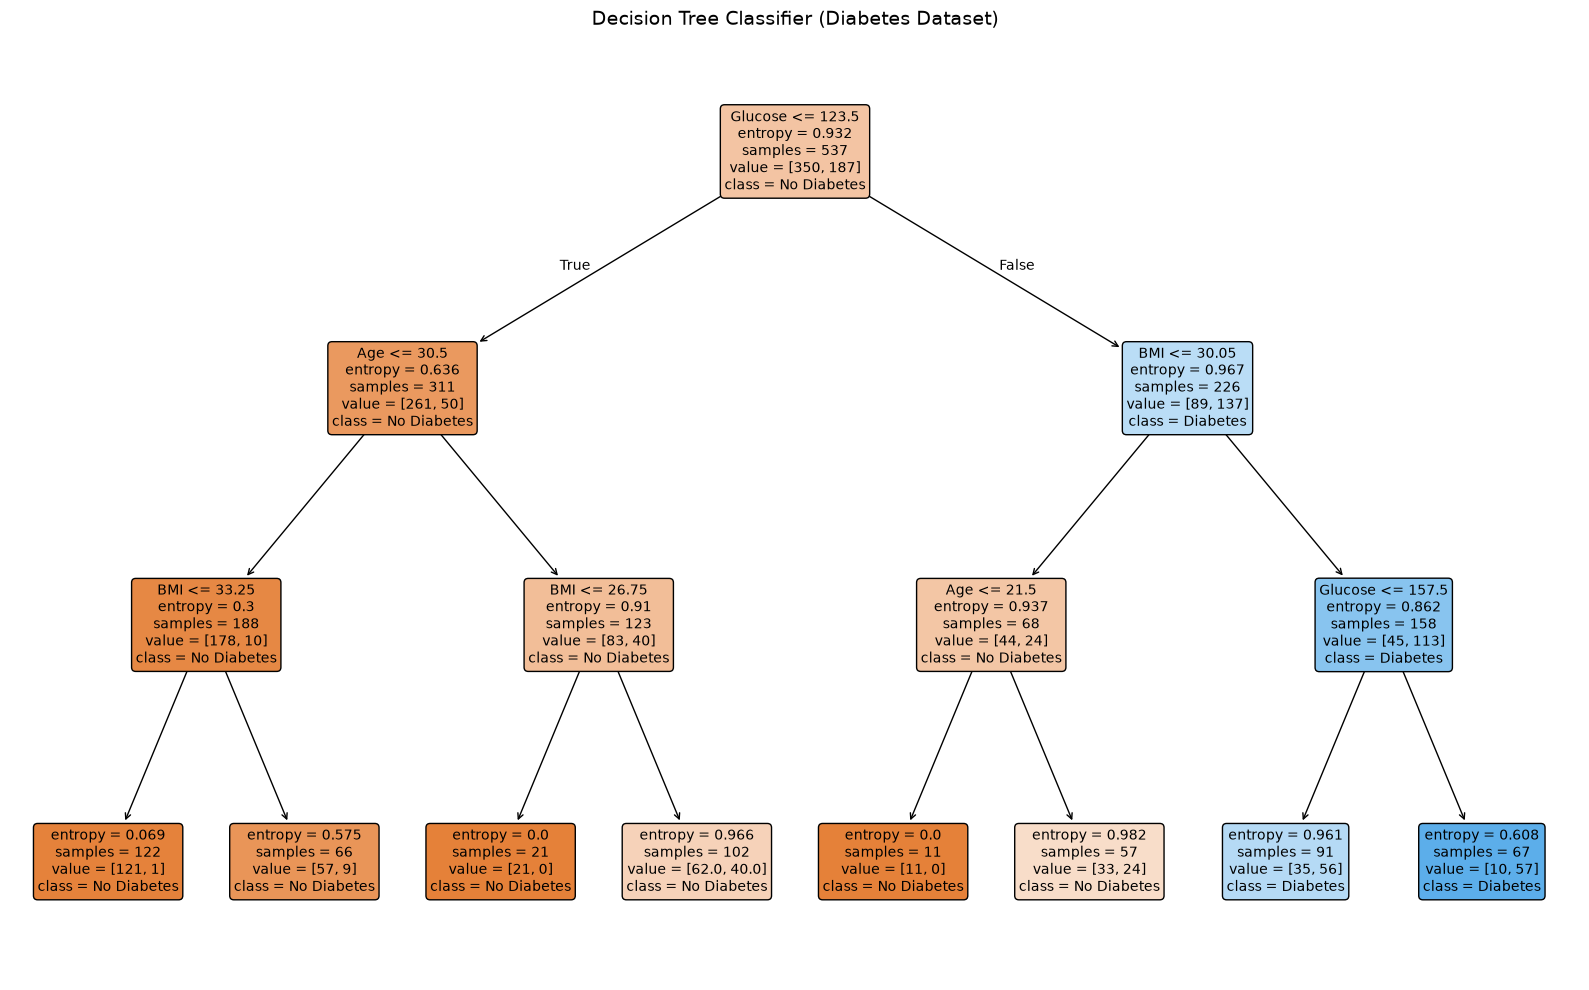

In [ ]:
# for own only


import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

# ----------------------------
# 1. Load dataset
# ----------------------------
df = pd.read_csv("../datasets/diabetes.csv")
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# ----------------------------
# 2. Split into training and test sets
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=101, stratify=y
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

# ----------------------------
# 3. Train Decision Tree Model
# ----------------------------
# Set max_depth to control tree size so the visual plot remains readable
model = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=101)
model.fit(X_train, y_train)

# ----------------------------
# 4. Evaluate on test set
# ----------------------------
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nTest Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
report = classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes'])
print(report)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# ----------------------------
# 5. Draw / Plot the Decision Tree
# ----------------------------
plt.figure(figsize=(16, 10))
plot_tree(
    model,
    feature_names=X.columns.tolist(),
    class_names=['No Diabetes', 'Diabetes'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Classifier (Diabetes Dataset)", fontsize=14)
plt.tight_layout()
plt.show()